# Confidence Weighted Fidelity Vs Geometry Weighted Fidelity

This notebook compares confidence-weighted fidelity against geometry-weighted fidelity.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Data Preparation

In this section, we load the datasets and prepare the data loaders or standard scaler transformations necessary for training.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy import stats

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [4]:
# -----------------------------------------------------------------------------
# Dataset generators
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, random_state=42):
    rng = np.random.default_rng(random_state)

    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])

    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)

    X = np.vstack([X0, X1])
    y = np.concatenate([
        np.zeros(n0, dtype=int),
        np.ones(n1, dtype=int)
    ])

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=0.25, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, random_state=random_state)
    raise ValueError(f"Unknown dataset: {name}")


### Model Training

Here we initialize and train the teacher models, followed by the respective surrogate approximation models.

In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor, y_tensor),
        batch_size=batch_size,
        shuffle=True,
    )

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()

    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()

    return probs


In [6]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)

    elif name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)

    elif name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)

    elif name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)

    elif name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )

    else:
        raise ValueError(f"Unknown surrogate: {name}")

    model.fit(X_train, teacher_train_y)
    return model


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Confidence vs. Geometry Correlation

We directly compare confidence-based weighting (using logits) against geometry-based weighting (using physical Euclidean distance to the approximated boundary) to show they capture the same underlying spatial phenomenon.

In [7]:
# -----------------------------------------------------------------------------
# Fidelity and weighting functions
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def teacher_margin(teacher_p):
    return np.abs(teacher_p - 0.5)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)

    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan

    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(teacher_p, alpha=10.0):
    margins = teacher_margin(teacher_p)
    return np.exp(-alpha * margins)


def geometry_weights(boundary_distances, beta=2.0):
    return np.exp(-beta * boundary_distances)


In [8]:
# -----------------------------------------------------------------------------
# Boundary approximation
# -----------------------------------------------------------------------------

def make_grid(X, margin=0.75, grid_size=350):
    x_min = X[:, 0].min() - margin
    x_max = X[:, 0].max() + margin

    y_min = X[:, 1].min() - margin
    y_max = X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def approximate_boundary_points(teacher, X_reference, grid_size=350, margin=0.75, band_eps=0.015):
    xx, yy, grid = make_grid(X_reference, margin=margin, grid_size=grid_size)

    grid_p = teacher_probs(teacher, grid)
    margins = np.abs(grid_p - 0.5)

    boundary_points = grid[margins <= band_eps]

    return {
        "xx": xx,
        "yy": yy,
        "grid": grid,
        "grid_p": grid_p,
        "boundary_points": boundary_points,
    }


def nearest_boundary_distances(X_eval, boundary_points):
    tree = cKDTree(boundary_points)
    distances, _ = tree.query(X_eval, k=1)
    return distances


In [9]:
# -----------------------------------------------------------------------------
# Main experiment
# -----------------------------------------------------------------------------

def run_one_case(dataset_name, seed, surrogate_name, conf_alpha=10.0, geo_beta=2.0):
    X, y = load_dataset(dataset_name, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.35,
        random_state=seed,
        stratify=y,
    )

    teacher = train_teacher(X_train, y_train, seed=seed)

    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    teacher_test_p = teacher_probs(teacher, X_test)

    surrogate = fit_surrogate(
        surrogate_name,
        X_train,
        teacher_train_y,
        seed=seed,
    )

    surrogate_test_p = surrogate_probs(surrogate, X_test)

    agreement = hard_agreement(teacher_test_p, surrogate_test_p)

    boundary_info = approximate_boundary_points(teacher, X_reference=X)

    distances = nearest_boundary_distances(
        X_test,
        boundary_info["boundary_points"],
    )

    conf_w = confidence_weights(teacher_test_p, alpha=conf_alpha)
    geo_w = geometry_weights(distances, beta=geo_beta)

    global_fidelity = float(np.mean(agreement))
    conf_fidelity = normalized_weighted_average(agreement, conf_w)
    geo_fidelity = normalized_weighted_average(agreement, geo_w)

    correlation = stats.spearmanr(
        teacher_margin(teacher_test_p),
        distances,
    ).correlation

    return {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "global_fidelity": global_fidelity,
        "confidence_weighted_fidelity": conf_fidelity,
        "geometry_weighted_fidelity": geo_fidelity,
        "confidence_minus_geometry": conf_fidelity - geo_fidelity,
        "margin_distance_spearman": correlation,
    }


In [10]:
# -----------------------------------------------------------------------------
# Run experiments
# -----------------------------------------------------------------------------

datasets = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "xor",
    "checkerboard",
    "circles",
]

surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

seeds = list(range(5))

rows = []

for dataset_name in datasets:
    print(f"\n=== Dataset: {dataset_name} ===")

    for seed in seeds:
        print(f"  seed {seed}")

        for surrogate_name in surrogates:
            row = run_one_case(
                dataset_name,
                seed,
                surrogate_name,
            )

            rows.append(row)

results = pd.DataFrame(rows)
results



=== Dataset: moons ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: warped_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: gaussian_overlap ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: linear_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: xor ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: checkerboard ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: circles ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4


,dataset,seed,surrogate,global_fidelity,confidence_weighted_fidelity,geometry_weighted_fidelity,confidence_minus_geometry,margin_distance_spearman
0,moons,0,logistic_regression,0.883810,0.724128,0.792097,-0.067970,0.798174
1,moons,0,linear_svm_calibrated,0.883810,0.724128,0.792097,-0.067970,0.798174
2,moons,0,decision_tree_depth_2,0.929524,0.712581,0.859526,-0.146945,0.798174
3,moons,0,decision_tree_depth_4,0.929524,0.712581,0.859526,-0.146945,0.798174
4,moons,0,small_mlp_surrogate,0.883810,0.724117,0.792098,-0.067981,0.798174
...,...,...,...,...,...,...,...,...
170,circles,4,logistic_regression,0.622857,0.578779,0.590527,-0.011747,0.931242
171,circles,4,linear_svm_calibrated,0.523810,0.515265,0.507432,0.007833,0.931242
172,circles,4,decision_tree_depth_2,0.754286,0.631249,0.716536,-0.085287,0.931242
173,circles,4,decision_tree_depth_4,0.958095,0.763370,0.922921,-0.159551,0.931242


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [11]:
results.to_csv("geometry_vs_confidence_results.csv", index=False)
print("Saved geometry_vs_confidence_results.csv")


Saved geometry_vs_confidence_results.csv


In [12]:
summary = (
    results
    .groupby("dataset")
    .agg(
        global_fidelity_mean=("global_fidelity", "mean"),
        confidence_weighted_mean=("confidence_weighted_fidelity", "mean"),
        geometry_weighted_mean=("geometry_weighted_fidelity", "mean"),
        confidence_minus_geometry_mean=("confidence_minus_geometry", "mean"),
        margin_distance_spearman_mean=("margin_distance_spearman", "mean"),
    )
)

summary


,global_fidelity_mean,confidence_weighted_mean,geometry_weighted_mean,confidence_minus_geometry_mean,margin_distance_spearman_mean
dataset,,,,,
checkerboard,0.566019,0.504638,0.557301,-0.052662,0.916549
circles,0.744838,0.604724,0.711918,-0.107194,0.939979
gaussian_overlap,0.879010,0.706577,0.797730,-0.091153,0.928199
linear_blobs,0.996648,0.960753,0.987493,-0.026740,0.530984
moons,0.903314,0.637473,0.821617,-0.184144,0.774336
warped_blobs,0.991543,0.867445,0.971206,-0.103761,0.745895
xor,0.740267,0.635570,0.714364,-0.078795,0.974150


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

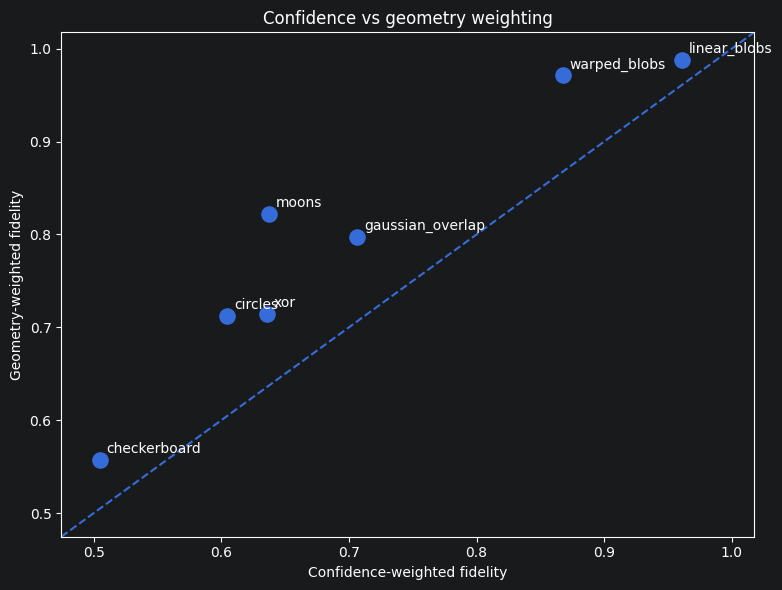

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    summary["confidence_weighted_mean"],
    summary["geometry_weighted_mean"],
    s=120,
)

for dataset_name, row in summary.iterrows():
    ax.annotate(
        dataset_name,
        (
            row["confidence_weighted_mean"],
            row["geometry_weighted_mean"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

lo = min(
    summary["confidence_weighted_mean"].min(),
    summary["geometry_weighted_mean"].min(),
) - 0.03

hi = max(
    summary["confidence_weighted_mean"].max(),
    summary["geometry_weighted_mean"].max(),
) + 0.03

ax.plot([lo, hi], [lo, hi], linestyle="--")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel("Confidence-weighted fidelity")
ax.set_ylabel("Geometry-weighted fidelity")
ax.set_title("Confidence vs geometry weighting")

plt.tight_layout()
plt.show()
